In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import cv2 as cv
from glob import glob
from torch.utils.data import Dataset, DataLoader
from diffusers.models import UNet2DModel
from torchvision.transforms import functional as tvf
from thop import profile
import rasterio as rio

# from torchvision.transforms import 
import os
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
# from torch.cuda.amp import autocast, GradScaler
from torch import autocast
from torch.amp import GradScaler
from torchvision.models import vgg19, VGG19_Weights
from typing import Optional, Union, List, Tuple
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from joblib import dump, load
from torchmetrics import functional as tmf
import pandas as pd


/home/dhester/diffusion-examples/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [43]:
class StandardDataAugmentations:
    '''
    Simple data augmentation that applies random rotation, horizontal, and vertical flips.
    Applies the same random transforms to all input tensors.
    '''
    @staticmethod
    def __call__(*images: torch.Tensor):
        # Generate random transforms
        do_hflip = torch.rand(1) > 0.5
        do_vflip = torch.rand(1) > 0.5
        rot_angle = torch.randint(0, 4, (1,)).item() * 90

        transformed = []
        for img in images:
            if do_hflip:
                img = tvf.hflip(img)
            if do_vflip:
                img = tvf.vflip(img)
            img = tvf.rotate(img, rot_angle)
            transformed.append(img)
        return tuple(transformed)
    
class NAIPDataset(Dataset):
    
    def __init__(self, 
        # s2_filepaths: Union[List[str], Tuple[str]], 
        # ps_filepaths: Union[List[str], Tuple[str]], 
        path: str,
        ids: List[str],
        s2_subdir: str='sentinel2',
        lcmap_subdir: str='lcmap',
        naip_subdir: str='naip',
        transforms: Optional[StandardDataAugmentations] = None
    ):
        super().__init__()
        
        self.path = path
        self.ids = ids
        self.s2_subdir = s2_subdir
        self.lcmap_subdir = lcmap_subdir
        self.naip_subdir = naip_subdir
        self.transforms = transforms
        
    def __len__(self):
        return len(self.ids)
        
    @staticmethod
    def _scale(
        data, 
        in_range: Union[Tuple[int, int], Tuple[float, float]]=(0, 10000), 
        out_range: Union[Tuple[int, int], Tuple[float, float]]=(-1.0, 1.0)
    ) -> torch.Tensor:
        
        # scale to 0-1
        data = (data - in_range[0]) / (in_range[1] - in_range[0])
        
        # scale to out_range
        data = data * (out_range[1] - out_range[0]) + out_range[0]
        data = data.clamp(min=out_range[0], max=out_range[1])
        return data

    
    def get_naip(self, idx):
        
        naip = torch.as_tensor(rio.open(os.path.join(self.path, self.naip_subdir, self.ids[idx] + '.tif')).read())
        return self._scale(naip.float())
    
    
    def __getitem__(self, idx):
        # return self.get_ps_img(idx, harmonize=True, return_s2_img=True)
        # s2_img, ps_img = self.get_s2_img(idx), self.get_ps_img(idx)
        
        s2 = torch.as_tensor(rio.open(os.path.join(self.path, self.s2_subdir, self.ids[idx] + '.tif')).read())
        lcmap = torch.as_tensor(rio.open(os.path.join(self.path, self.lcmap_subdir, self.ids[idx] + '.tif')).read(1))
        naip = torch.as_tensor(rio.open(os.path.join(self.path, self.naip_subdir, self.ids[idx] + '.tif')).read())
        
        s2 = self._scale(s2.float())
        naip = self._scale(naip.float())
        
        label_map = {
            1: 0,   # Water
            2: 1,   # Trees
            4: 2,   # Flooded Vegetation
            5: 3,   # Crops
            7: 4,   # Built Area
            8: 5,   # Bare Ground
            9: 6,   # Snow/Ice
            11: 7,  # Rangeland
            # 10: clouds, will be all zeros
        }

        lcmap_mapped = torch.full_like(lcmap, fill_value=255)  # 255 = invalid

        for orig, mapped in label_map.items():
            lcmap_mapped[lcmap == orig] = mapped

        mask_clouds = (lcmap == 10) | (lcmap_mapped == 255)
        lcmap_mapped[mask_clouds] = 0
        lcmap_onehot = F.one_hot(lcmap_mapped.long(), num_classes=8)  # shape (H, W, 8)
        lcmap_onehot[mask_clouds] = 0
        lcmap_onehot = lcmap_onehot.permute(2, 0, 1).float()
        
        if self.transforms is not None:
            return self.transforms(s2, lcmap_onehot, naip)
        else:
            return s2, lcmap_onehot, naip


random.seed(1701)

s2_files = glob(os.path.join('..', 's2_naip_pairs', 'sentinel2', '*.tif'))
lcmap_files = glob(os.path.join('..', 's2_naip_pairs', 'lcmap', '*.tif'))
naip_files = glob(os.path.join('..', 's2_naip_pairs', 'naip', '*.tif'))

s2_ids = [path.split(os.sep)[-1].replace('.tif', '') for path in s2_files]
lcmap_ids = [path.split(os.sep)[-1].replace('.tif', '') for path in lcmap_files]
naip_ids = [path.split(os.sep)[-1].replace('.tif', '') for path in naip_files]

all_ids = [idfr for idfr in s2_ids if (idfr in lcmap_ids) and (idfr in naip_ids)]
val_ids = random.sample(all_ids, k=int(0.1*len(all_ids)))
train_ids = [idfr for idfr in all_ids if idfr not in val_ids]

train_dataset = NAIPDataset(os.path.join('..', 's2_naip_pairs'), ids=train_ids)
print(f'Number of samples in training dataset: {len(train_dataset)}')

val_dataset = NAIPDataset(os.path.join('..', 's2_naip_pairs'), ids=val_ids)
print(f'Number of samples in validation dataset: {len(val_dataset)}')


Number of samples in training dataset: 153023
Number of samples in validation dataset: 17002


In [77]:
pca_pipeline_path = os.path.join('..', 'models', 'pca_pipeline.joblib')
if os.path.exists(pca_pipeline_path):
    pca_pipeline = load(pca_pipeline_path)
else:
    X = np.concat([train_dataset.get_naip(i).numpy().transpose(1, 2, 0).reshape(-1, 4) for i in range(len(train_dataset))])
    pca_pipeline = make_pipeline(
        StandardScaler(),
        PCA(n_components=3)
    )
    pca_pipeline.fit(X)
    dump(pca_pipeline, pca_pipeline_path)

In [4]:
class PerceptualLoss(nn.Module):
    
    def __init__(self, pca_pipeline=None, device='cpu', reduction='batch'):
        super().__init__()
        
        self.device = device
        self.reduction = reduction

        if pca_pipeline is not None:
            self.pca_conv = self._create_pca_conv_layer(pca_pipeline).to(self.device)
            self.pca_conv.requires_grad_(False)
        
        self.vgg_feature_extractor = vgg19(weights=VGG19_Weights.IMAGENET1K_V1).features.to(self.device).eval()
        for p in self.vgg_feature_extractor.parameters():
            p.requires_grad_(False)
        
        self.feature_layers = [2, 7, 16, 25, 34]
        self.layer_weights = [0.1, 0.1, 1.0, 1.0, 1.0]
                
        if self.reduction == 'batch':            
            self.mae_loss = nn.L1Loss(reduction='none')
        else:
            self.mae_loss = nn.L1Loss(reduction=self.reduction)

    @staticmethod
    def _create_pca_conv_layer(pca_pipeline) -> nn.Conv2d:
        """Creates a frozen 1x1 Conv2D layer from scaler and PCA stats."""
        mu = pca_pipeline['standardscaler'].mean_
        sigma = pca_pipeline['standardscaler'].scale_
        V_T = pca_pipeline['pca'].components_.T
        
        W = np.diag(1 / sigma) @ V_T
        b = - (mu / sigma) @ V_T
        
        pca_conv = nn.Conv2d(4, 3, kernel_size=1, stride=1, bias=True)
        
        weight_tensor = torch.from_numpy(W.T).float().unsqueeze(-1).unsqueeze(-1)
        bias_tensor = torch.from_numpy(b).float()
        
        with torch.no_grad():
            pca_conv.weight.copy_(weight_tensor)
            pca_conv.bias.copy_(bias_tensor)
            
        return pca_conv
    
    def extract_features(self, x):
        """Extract features from specified conv layers (pre-activation)."""
        features = []
        for i, layer in enumerate(self.vgg_feature_extractor):
            x = layer(x)
            if i in self.feature_layers:
                features.append(x)
        return features

    def forward(self, generated_img: torch.Tensor, target_img: torch.Tensor) -> torch.Tensor:
        """
        Computes the Real-ESRGAN style perceptual loss.
        """
        generated_img = generated_img.to(self.device)
        target_img = target_img.to(self.device)
        
        # Apply PCA conversion if needed
        if hasattr(self, 'pca_conv'):
            gen_pca = self.pca_conv(generated_img)
            tgt_pca = self.pca_conv(target_img)
        else:
            gen_pca, tgt_pca = generated_img, target_img
        
        # Extract VGG features
        gen_feats = self.extract_features(gen_pca)
        tgt_feats = self.extract_features(tgt_pca)
        
        # Compute weighted perceptual loss
        total_loss = 0.0
        for w, gf, tf in zip(self.layer_weights, gen_feats, tgt_feats):
            loss = self.mae_loss(gf, tf)
            if self.reduction == 'batch':
                loss = loss.mean(dim=(1, 2, 3))  # per-image mean
            total_loss += w * loss

        return total_loss

In [81]:
class PCAConvLayer(nn.Module):
    """
    1x1 conv that performs StandardScaler -> PCA projection (frozen).
    Provides helpers to scale the PCA channels to the range expected by LPIPS.
    """
    def __init__(self, pca_pipeline):
        super().__init__()
        
        mu = pca_pipeline['standardscaler'].mean_
        sigma = pca_pipeline['standardscaler'].scale_
        V_T = pca_pipeline['pca'].components_.T

        # weight/bias that map original 4-channel image -> PCA scores
        W = np.diag(1.0 / sigma) @ V_T
        b = - (mu / sigma) @ V_T

        self.pca_conv = nn.Conv2d(4, 3, kernel_size=1, stride=1, bias=True)

        weight_tensor = torch.from_numpy(W.T).float().unsqueeze(-1).unsqueeze(-1)
        bias_tensor = torch.from_numpy(b).float()

        with torch.no_grad():
            self.pca_conv.weight.copy_(weight_tensor)
            self.pca_conv.bias.copy_(bias_tensor)

        # freeze parameters
        for p in self.pca_conv.parameters():
            p.requires_grad = False

        # store per-component std (explained variance of PCA on standardized data)
        pca_var = pca_pipeline['pca'].explained_variance_  # shape (3,)
        pca_std = np.sqrt(pca_var).astype(np.float32)
        # register as buffer so it moves with the module and survives state_dict
        self.register_buffer('pca_std', torch.from_numpy(pca_std).view(1, 3, 1, 1))


    def forward(self, x):
        """Return raw PCA scores (B,3,H,W)."""
        return self.pca_conv(x)

    def to_lpips(self, x, k: Optional[float]=2.0, clamp: bool=True):
        """
        Convert original 4-ch input x -> scaled PCA image suitable for LPIPS.
        - k: number of stds that should map to 1.0 (default=2.0).
        Returns tensor in approximately [-1, 1] (clamped if clamp=True).
        """
        out = self.pca_conv(x)  # B,3,H,W
        std = self.pca_std.to(out.device).type_as(out)
        scaled = out / (k * std)
        return scaled.clamp(-1.0, 1.0) if clamp else scaled

pca_conv = PCAConvLayer(pca_pipeline).to(device)

In [13]:
# device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f'Using backed {device}')
if device.type == 'cuda' and torch.cuda.is_bf16_supported():
    print('bfloat16 is supported. Using for mixed precision.')
    mixed_precision_dtype = torch.bfloat16
else:
    print('bfloat16 not supported. Falling back to float16 for mixed precision.')
    mixed_precision_dtype = torch.float16

model = UNet2DModel(
    sample_size=256,
    in_channels=16,
    out_channels=4,
    # block_out_channels=[96, 192, 384, 768],
    block_out_channels=[64, 128, 256, 512],
    # block_out_channels=[48, 96, 192, 384],
    # block_out_channels=[32, 32, 32, 32],
    down_block_types=['DownBlock2D'] * 4, # + ['AttnDownBlock2D'],
    up_block_types=['UpBlock2D'] * 4, # + ['AttnUpBlock2D']
    # norm_num_groups=48,
)
model.to(device)
# model = torch.compile(model)


# shape must match the model forward signature (batch included)
input = torch.randn(1, 16, 256, 256).to(next(model.parameters()).device)

macs, params = profile(model, inputs=(input,0), verbose=False)
flops = 2 * macs   # convert MACs -> FLOPs (if you want multiply+add=2 FLOPs)
print(f"MACs: {macs:,}, Params: {params:,}, FLOPs: {flops:,}")

# print(f'Total U-Net parameters: {sum([p.numel() for p in model.parameters()])}')

Using backed cuda
bfloat16 is supported. Using for mixed precision.
MACs: 175,172,485,120.0, Params: 56,553,348.0, FLOPs: 350,344,970,240.0


In [25]:
def write_list_to_file(lst, filename):
    with open(filename, 'w') as f:
        for item in lst:
            f.write(f"{item}\n")
            
def colorize_onehot_lcmap(lcmap_onehot):
    """
    lcmap_onehot: torch.Tensor of shape (8, H, W) or (B, 8, H, W)
    Returns: np.ndarray of shape (H, W, 3) or (B, H, W, 3) with RGB colors
    """
    # Color palette for indices 0-7 (what the model sees)
    palette = np.array([
        [26, 91, 171],    # 0 Water
        [53, 130, 33],    # 1 Trees
        [135, 209, 158],  # 2 Flooded Vegetation
        [255, 219, 92],   # 3 Crops
        [237, 2, 42],     # 4 Built Area
        [237, 233, 228],  # 5 Bare Ground
        [242, 250, 255],  # 6 Snow/Ice
        [198, 173, 141],  # 7 Rangeland
    ], dtype=np.uint8)

    # If batched, shape is (B, 8, H, W)
    if lcmap_onehot.dim() == 4:
        lcmap_idx = lcmap_onehot.argmax(dim=1)  # (B, H, W)
        rgb = palette[lcmap_idx.cpu().numpy()]  # (B, H, W, 3)
    else:
        lcmap_idx = lcmap_onehot.argmax(dim=0)  # (H, W)
        rgb = palette[lcmap_idx.cpu().numpy()]  # (H, W, 3)
    return rgb

def inference(model, s2_img, lcmap, total_steps, use_rk4=False):
    
    device = model.device
    timesteps = torch.linspace(0, 1, total_steps, device=device)
    step_size = timesteps[1] - timesteps[0]
    
    naip_shape = list(s2_img.shape)
    naip_shape[1] = 4
    x = torch.randn(naip_shape, device=device)

    for t in tqdm(timesteps):
        t_batch = torch.ones(s2_img.shape[0], device=device) * t

        if use_rk4:
            t_mid_batch = torch.ones(s2_img.shape[0], device=device) * (t + step_size / 2)
            t_next_batch = torch.ones(s2_img.shape[0], device=device) * (t + step_size)

            with torch.no_grad(), autocast(device.type, dtype=mixed_precision_dtype):
                
                # k1: velocity at start of the step
                model_input_k1 = torch.cat((x, s2_img), dim=1)
                v_k1 = model(model_input_k1, t_batch * 1000).sample
                
                # k2: velocity at midpoint
                x_k2 = x + v_k1 * (step_size / 2)
                model_input_k2 = torch.cat((x_k2, s2_img), dim=1)
                v_k2 = model(model_input_k2, t_mid_batch * 1000).sample
                
                # k3: velocity at midpoint (estimated with k2)
                x_k3 = x + v_k2 * (step_size / 2)
                model_input_k3 = torch.cat((x_k3, s2_img), dim=1)
                v_k3 = model(model_input_k3, t_mid_batch * 1000).sample
                
                # k4: velocity at the end of the step
                x_k4 = x + v_k3 * step_size
                model_input_k4 = torch.cat((x_k4, s2_img), dim=1)
                v_k4 = model(model_input_k4, t_next_batch * 1000).sample
            
            x = x + (step_size / 6) * (v_k1 + 2*v_k2 + 2*v_k3 + v_k4)
        
        else:
            with torch.no_grad(), autocast(device.type, dtype=mixed_precision_dtype):
                model_input_k1 = torch.cat((x, s2_img), dim=1)
                v_k1 = model(model_input_k1, t_batch * 1000).sample
            x = x + v_k1 * step_size
            
    
    return x

In [ ]:
batch_size = 256
micro_batch_size = 32
n_epochs = 300
warmup_epochs = 10
lr = 1e-4
loss_lambda = 0.01 # l_total = l_l1 + lambda * l_percep

num_inference_timesteps = 10
samples_to_plot = 32

grad_accum_steps = batch_size // micro_batch_size

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, fused=torch.cuda.is_available())
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs-1)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs - warmup_epochs)
lr_scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[warmup_epochs])
scaler = GradScaler()
perceptual_loss = PerceptualLoss(pca_pipeline, device=device)

train_dataloader = DataLoader(train_dataset, batch_size=micro_batch_size, shuffle=True, drop_last=True, pin_memory=True, num_workers=16)
val_dataloader = DataLoader(val_dataset, batch_size=micro_batch_size, shuffle=False, drop_last=False, pin_memory=True, num_workers=16)

metrics = {
    'epoch': [],
    'lr': [],
}
for phase in ('train', 'val'):
    for metric in ('l1_loss', 'percep_loss', 'total_loss', 'ssim', 'mssim', 'psnr'):
        metrics[f'{phase}_{metric}'] = [] 

for epoch in range(1, n_epochs+1):
    
    metrics['epoch'].append(epoch)
    metrics['lr'].append(optimizer.param_groups[0]['lr'])
    
    epoch_metrics = {
        f'{phase}_{metric}': 0.0
        for metric in ('l1_loss', 'percep_loss', 'total_loss', 'ssim', 'mssim', 'psnr')
        for phase in ('train', 'val')
    }
    
    for phase in ('train', 'val'):
        if phase == 'train':
            loader = train_dataloader
            model.train()
            torch.set_grad_enabled(True)
            
        else:
            loader = val_dataloader
            model.eval()
            torch.set_grad_enabled(False)
            
        phase_count = 0
    
        with tqdm(loader, desc=f'Epoch {epoch}/{n_epochs} {phase.capitalize() + ('  ' if phase == 'val' else '')}', unit='batch', postfix={'lr': optimizer.param_groups[0]['lr']}) as pbar:
            for i, (s2_img, lcmap, naip_img) in enumerate(pbar):
                
                s2_img, lcamp, naip_img = s2_img.to(device), lcmap.to(device), naip_img.to(device)
                
                x_0 = torch.randn_like(naip_img) 
                t = torch.rand(x_0.shape[0], device=device)
                t_reshaped = t.view(-1, 1, 1, 1)
                
                # interpolated point on the path (linear interpolation)
                x_t = (1 - t_reshaped) * x_0 + t_reshaped * naip_img
                target_vector = naip_img - x_0 # target vector field
                unet_input = torch.cat((x_t, s2_img, lcamp), dim=1)

                with autocast(device.type, dtype=mixed_precision_dtype):
                    pred_vector = model(unet_input, t * 1000).sample
                    l1_loss = F.l1_loss(pred_vector, target_vector, reduction='none').mean(dim=(1, 2, 3))
                    percep_loss = perceptual_loss(pred_vector + x_0, naip_img)
                    
                total_loss = l1_loss + loss_lambda * percep_loss
                pred_img = (pred_vector + x_0).detach().clip(-1, 1)
                
                phase_count += s2_img.shape[0]
                epoch_metrics[f'{phase}_l1_loss']     += l1_loss.detach().sum().item()
                epoch_metrics[f'{phase}_percep_loss'] += percep_loss.detach().sum().item()
                epoch_metrics[f'{phase}_total_loss']  += total_loss.detach().sum().item()
                epoch_metrics[f'{phase}_ssim']        += tmf.image.structural_similarity_index_measure(pred_img, naip_img.detach(), data_range=(-1, 1), reduction='none').sum().item()
                epoch_metrics[f'{phase}_mssim']       += tmf.image.multiscale_structural_similarity_index_measure(pred_img, naip_img.detach(), data_range=(-1, 1), reduction='none').sum().item()
                epoch_metrics[f'{phase}_psnr']        += tmf.image.peak_signal_noise_ratio(pred_img, naip_img.detach(), data_range=(-1, 1), reduction='none', dim=(1, 2, 3)).sum().item()

                if phase == 'train':
                    scaler.scale(total_loss.mean()).backward()
                    if (i + 1) % grad_accum_steps == 0:
                        scaler.step(optimizer)
                        scaler.update()
                        optimizer.zero_grad()
                
                pbar_postfix = {'lr': f'{optimizer.param_groups[0]["lr"]:.2e}'}
                for metric in ('l1_loss', 'percep_loss', 'total_loss', 'ssim', 'mssim', 'psnr'):
                    avg = epoch_metrics[f'{phase}_{metric}'] / phase_count
                    pbar_postfix[metric] = f'{avg:.2e}'
                pbar.set_postfix(pbar_postfix)
                                                    
        for metric in ('l1_loss', 'percep_loss', 'total_loss', 'ssim', 'mssim', 'psnr'):
            epoch_metrics[f'{phase}_{metric}'] /= phase_count
            metrics[f'{phase}_{metric}'].append(epoch_metrics[f'{phase}_{metric}'])
                
    pd.DataFrame(metrics).to_csv('../logs/fm_s2_naip_sr_4x_percep.csv', index=False)
    torch.save(model.state_dict(), '../models/fm_s2_naip_sr_4x_percep.pt')
    lr_scheduler.step()
    
    if epoch % 20 == 0:
        model.eval()
        
        s2_img = torch.stack([val_dataset[i][0] for i in range(samples_to_plot)], dim=0)
        lcmap = torch.stack([val_dataset[i][1] for i in range(samples_to_plot)], dim=0)
        naip_img = torch.stack([val_dataset[i][2] for i in range(samples_to_plot)], dim=0)
        
        pred = inference(model, s2_img.to(device), lcmap.to(device), num_inference_timesteps)
        
        s2_img = (s2_img + 1).clip(0, 1)
        naip_img = (naip_img + 1).clip(0, 1)
        pred_img = (pred + 1).clip(0, 1)
        lcmap_rgb = colorize_onehot_lcmap(lcmap)

        s2_img_rgb = torch.stack((
            s2_img[:, 3],
            s2_img[:, 2],
            s2_img[:, 1],
        ), dim=1).detach().cpu().float().permute(0, 2, 3, 1)

        s2_img_cir = torch.stack((
            s2_img[:, 7],
            s2_img[:, 3],
            s2_img[:, 2],
        ), dim=1).detach().cpu().float().permute(0, 2, 3, 1)

        naip_img_rgb = torch.stack((
            naip_img[:, 0],
            naip_img[:, 1],
            naip_img[:, 2],
        ), dim=1).detach().cpu().float().permute(0, 2, 3, 1)

        naip_img_cir = torch.stack((
            naip_img[:, 3],
            naip_img[:, 0],
            naip_img[:, 1],
        ), dim=1).detach().cpu().float().permute(0, 2, 3, 1)

        pred_img_rgb = torch.stack((
            pred_img[:, 0],
            pred_img[:, 1],
            pred_img[:, 2],
        ), dim=1).detach().cpu().float().permute(0, 2, 3, 1)

        pred_img_cir = torch.stack((
            pred_img[:, 3],
            pred_img[:, 0],
            pred_img[:, 1],
        ), dim=1).detach().cpu().float().permute(0, 2, 3, 1)

        fig, axes = plt.subplots(7, samples_to_plot, figsize=(3*samples_to_plot, 21))

        for i, ax in enumerate(axes.T):        
            
            ax[0].imshow(s2_img_rgb[i])
            ax[1].imshow(s2_img_cir[i])
            ax[2].imshow(lcmap_rgb[i])
            ax[3].imshow(pred_img_rgb[i])
            ax[4].imshow(naip_img_rgb[i])
            ax[5].imshow(pred_img_cir[i]) 
            ax[6].imshow(naip_img_cir[i])
            
            for a in ax:
                a.axis('off')

        fig.suptitle(f'Epoch {epoch}/{n_epochs}')
        fig.tight_layout()
        plt.show()

In [102]:
model.load_state_dict(torch.load('../models/fm_s2_naip_sr_10x.pt'))
model.eval()

num_inference_timesteps = 50
samples_to_plot = 64

s2_img = torch.stack([val_dataset[i + 3*samples_to_plot][0] for i in range(samples_to_plot)], dim=0)
lcmap = torch.stack([val_dataset[i + 3*samples_to_plot][1] for i in range(samples_to_plot)], dim=0)
naip_img = torch.stack([val_dataset[i + 3*samples_to_plot][2] for i in range(samples_to_plot)], dim=0)

pred = inference(model, s2_img.to(device), lcmap.to(device), num_inference_timesteps, use_rk4=False)

l1_loss = F.l1_loss(pred, naip_img.to(device), reduction='none').mean(dim=(1, 2, 3))
ssim = tmf.image.structural_similarity_index_measure(pred, naip_img.to(device), data_range=(-1, 1), reduction='none')
mssim = tmf.image.multiscale_structural_similarity_index_measure(pred, naip_img.to(device), data_range=(-1, 1), reduction='none')
psnr = tmf.image.peak_signal_noise_ratio(pred, naip_img.to(device), data_range=(-1, 1), reduction='none', dim=(1, 2, 3))
lpips = tmf.image.learned_perceptual_image_patch_similarity(pca_conv.to_lpips(pred), pca_conv.to_lpips(naip_img.to(device).detach()), reduction='none')

s2_img = (s2_img + 1).clip(0, 1)
naip_img = (naip_img + 1).clip(0, 1)
pred_img = (pred + 1).clip(0, 1)
lcmap_rgb = colorize_onehot_lcmap(lcmap)

s2_img_rgb = torch.stack((
    s2_img[:, 3],
    s2_img[:, 2],
    s2_img[:, 1],
), dim=1).detach().cpu().float().permute(0, 2, 3, 1)

s2_img_cir = torch.stack((
    s2_img[:, 7],
    s2_img[:, 3],
    s2_img[:, 2],
), dim=1).detach().cpu().float().permute(0, 2, 3, 1)

naip_img_rgb = torch.stack((
    naip_img[:, 0],
    naip_img[:, 1],
    naip_img[:, 2],
), dim=1).detach().cpu().float().permute(0, 2, 3, 1)

naip_img_cir = torch.stack((
    naip_img[:, 3],
    naip_img[:, 0],
    naip_img[:, 1],
), dim=1).detach().cpu().float().permute(0, 2, 3, 1)

pred_img_rgb = torch.stack((
    pred_img[:, 0],
    pred_img[:, 1],
    pred_img[:, 2],
), dim=1).detach().cpu().float().permute(0, 2, 3, 1)

pred_img_cir = torch.stack((
    pred_img[:, 3],
    pred_img[:, 0],
    pred_img[:, 1],
), dim=1).detach().cpu().float().permute(0, 2, 3, 1)


100%|██████████| 50/50 [00:36<00:00,  1.37it/s]


In [ ]:
fig, axes = plt.subplots(6, samples_to_plot, figsize=(2*samples_to_plot, 12))

rgb_gain = 2.5
cir_gain = 1.4

for i, ax in enumerate(axes.T):  
    
    s2_rgb = (s2_img_rgb[i].numpy() * rgb_gain).clip(0, 1)
    s2_cir = (s2_img_cir[i].numpy() * cir_gain).clip(0, 1)
    naip_rgb = (naip_img_rgb[i].numpy() * rgb_gain).clip(0, 1)
    naip_cir = (naip_img_cir[i].numpy() * cir_gain).clip(0, 1)
    pred_rgb = (pred_img_rgb[i].numpy() * rgb_gain).clip(0, 1)
    pred_cir = (pred_img_cir[i].numpy() * cir_gain).clip(0, 1)      
    
    ax[0].imshow(s2_rgb)
    ax[1].imshow(s2_cir)
    ax[2].imshow(pred_rgb)
    ax[3].imshow(naip_rgb)
    ax[4].imshow(pred_cir)
    ax[5].imshow(naip_cir)
    
    for a in ax:
        a.set_xticks([])
        a.set_yticks([])
        a.set_xticklabels([])
        a.set_yticklabels([])
    
    ax[5].set_xlabel(f'MAE: {l1_loss[i]:.4f}\nSSIM: {ssim[i]:.4f}\nMS-SSIM: {mssim[i]:.4f}\nPSNR: {psnr[i]:.2f} dB\nLPIPS: {lpips[i]:.4f}', fontsize=8)

axes[0][0].set_ylabel('S2 RGB')
axes[1][0].set_ylabel('S2 CIR')
# axes[2][0].set_ylabel('ESRI 10m LCMAP')
axes[2][0].set_ylabel(f'SR RGB')
axes[3][0].set_ylabel('NAIP RGB')
axes[4][0].set_ylabel('SR CIR')
axes[5][0].set_ylabel('NAIP CIR')

fig.tight_layout()
plt.show()

In [ ]:
# save examples of each to output folder
output_dir = '../outputs/fm_s2_naip_sr_10x_percep'
os.makedirs(output_dir, exist_ok=True)

rgb_gain = 2.5
cir_gain = 1.4

for i in range(samples_to_plot):
    
    os.makedirs(os.path.join(output_dir, f'sample_{i:02d}'), exist_ok=True)
    
    s2_rgb = (s2_img_rgb[i].numpy() * rgb_gain).clip(0, 1)
    s2_cir = (s2_img_cir[i].numpy() * cir_gain).clip(0, 1)
    naip_rgb = (naip_img_rgb[i].numpy() * rgb_gain).clip(0, 1)
    naip_cir = (naip_img_cir[i].numpy() * cir_gain).clip(0, 1)
    pred_rgb = (pred_img_rgb[i].numpy() * rgb_gain).clip(0, 1)
    pred_cir = (pred_img_cir[i].numpy() * cir_gain).clip(0, 1)
    
    cv.imwrite(os.path.join(output_dir, f'sample_{i:02d}', f's2_rgb.png'), (s2_rgb * 255).astype(np.uint8)[:,:,::-1])
    cv.imwrite(os.path.join(output_dir, f'sample_{i:02d}', f's2_cir.png'), (s2_cir * 255).astype(np.uint8)[:,:,::-1])
    cv.imwrite(os.path.join(output_dir, f'sample_{i:02d}', f'naip_rgb.png'), (naip_rgb * 255).astype(np.uint8)[:,:,::-1])
    cv.imwrite(os.path.join(output_dir, f'sample_{i:02d}', f'naip_cir.png'), (naip_cir * 255).astype(np.uint8)[:,:,::-1])
    cv.imwrite(os.path.join(output_dir, f'sample_{i:02d}', f'pred_rgb.png'), (pred_rgb * 255).astype(np.uint8)[:,:,::-1])
    cv.imwrite(os.path.join(output_dir, f'sample_{i:02d}', f'pred_cir.png'), (pred_cir * 255).astype(np.uint8)[:,:,::-1])

In [ ]:
batch = np.zeros()

In [ ]:
for naip_img, s2_img in batch:
    x_0 = torch.randn_like(naip_img) # Start with pure noise
    t = torch.rand(naip_img.shape[0]) # Pick a random time t ~ U(0, 1)
    x_t = (1 - t) * x_0 + t * naip_img # Linearly interpolate to get a noisy image x_t

    # The direction from noise to the real image - this is what we are trying to predict
    target_vector = naip_img - x_0              

    unet_input = torch.cat([x_t, s2_img], dim=1)
    pred_vector = model(unet_input, t) # Model predicts the direction

    # Calculate loss and update the model's parameters
    loss = F.l1_loss(pred_vector, target_vector) # Mean absolute error
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [ ]:
x = torch.randn_like(s2_img) # Start with pure noise
N_STEPS = 50 # Number of steps to take

# Iteratively follow the model's predicted vector field
for t in torch.linspace(0, 1, N_STEPS):
    # Predict the direction vector `v` at the current position `x` and time `t`
    unet_input = torch.cat([x, s2_img], dim=1)
    v = model(unet_input, t)

    # Take a small step in the predicted direction (Euler integration)
    x = x + v * (1 / N_STEPS)

# The final `x` is the generated high-resolution image
generated_naip = x

<Axes: >

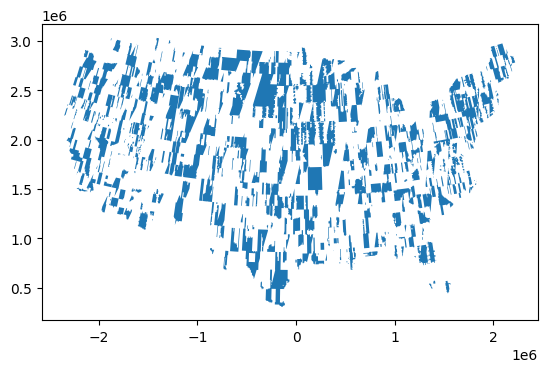

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

candidate_regions = gpd.read_parquet('../s2_naip_pairs_4x/candidate_regions.par')
candidate_regions.plot()